## Lab 4: KNN Classification on the Breast Cancer Dataset

Aim: build a KNN classifier on the Breast Cancer Wisconsin dataset and compare classification metrics against the regression metrics from Lab 3.

### Step 0 — Imports

Standard stack: pandas/numpy for data handling, matplotlib/seaborn for plots, sklearn for the model and metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


### Task 1.1 — Load the dataset from sklearn

In [2]:
data = load_breast_cancer()

print("Dataset loaded successfully.")
print(f"Number of samples : {data.data.shape[0]}")
print(f"Number of features: {data.data.shape[1]}")
print(f"Target classes    : {dict(zip(data.target_names, range(len(data.target_names))))}")
print()
print("Feature names:")
print(list(data.feature_names))

Dataset loaded successfully.
Number of samples : 569
Number of features: 30
Target classes    : {np.str_('malignant'): 0, np.str_('benign'): 1}

Feature names:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimensi

### 1.2 — Convert to a DataFrame and take a first look

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Observation:** all 30 features are continuous measurements from the digitized images, and they're on very different scales (e.g. area is in the hundreds while smoothness is around 0.1).

### 1.3 — Check for missing values and duplicates

In [6]:
print("Missing values per column (top 5 shown, rest are 0):")
print(df.isnull().sum().sort_values(ascending=False).head())
print(f"\nTotal missing values in the dataset: {df.isnull().sum().sum()}")

n_dupes = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {n_dupes}")

print(f"\nClass balance:")
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True).round(4) * 100, "%")

Missing values per column (top 5 shown, rest are 0):
mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64

Total missing values in the dataset: 0

Number of duplicate rows: 0

Class balance:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64
diagnosis
Benign       62.74
Malignant    37.26
Name: proportion, dtype: float64 %


**Observation:** no missing values or duplicates (it's the pre-cleaned sklearn copy), but the classes are a bit imbalanced — about 63% benign vs 37% malignant — so accuracy alone won't tell the full story later.

### 1.4 — Scale the features with StandardScaler

KNN is distance-based, so without scaling a feature like mean area would completely dominate over something like mean smoothness even though both are informative.

In [7]:
X = df[data.feature_names].values
y = df["target"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — example feature ranges:")
print(pd.DataFrame(X, columns=data.feature_names)[["mean area", "mean smoothness"]].describe().loc[["min", "max"]])

print("\nAfter scaling — same features (mean ~0, std ~1):")
print(pd.DataFrame(X_scaled, columns=data.feature_names)[["mean area", "mean smoothness"]].describe().loc[["mean", "std", "min", "max"]].round(3))

Before scaling — example feature ranges:
     mean area  mean smoothness
min      143.5          0.05263
max     2501.0          0.16340

After scaling — same features (mean ~0, std ~1):
      mean area  mean smoothness
mean     -0.000            0.000
std       1.001            1.001
min      -1.454           -3.112
max       5.251            4.771


### Task 2 — Train/test split analysis

Comparing 80:20, 70:30, and 90:10 splits to see how much the ratio actually moves accuracy.

In [8]:
split_ratios = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10,
}

split_results = []
split_data = {}  # keep the actual splits for later reuse

for label, test_size in split_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    knn_baseline = KNeighborsClassifier(n_neighbors=5)
    knn_baseline.fit(X_train, y_train)
    y_pred = knn_baseline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    split_data[label] = (X_train, X_test, y_train, y_test)
    split_results.append({
        "Split": label,
        "Train size": len(X_train),
        "Test size": len(X_test),
        "Accuracy (K=5)": round(acc, 4)
    })

split_df = pd.DataFrame(split_results)
split_df

,Split,Train size,Test size,Accuracy (K=5)
0,80:20,455,114,0.9649
1,70:30,398,171,0.9708
2,90:10,512,57,0.9825


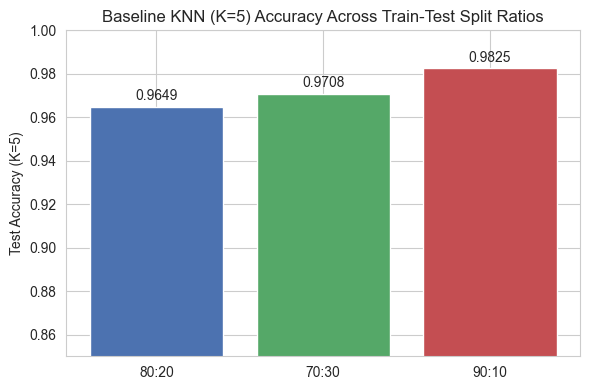

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(split_df["Split"], split_df["Accuracy (K=5)"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylim(0.85, 1.0)
plt.ylabel("Test Accuracy (K=5)")
plt.title("Baseline KNN (K=5) Accuracy Across Train-Test Split Ratios")
for i, v in enumerate(split_df["Accuracy (K=5)"]):
    plt.text(i, v + 0.003, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()

**Observation:** all three splits land within about 1-2% of each other since the dataset's a decent size and `stratify=y` keeps the class ratio consistent — the 90:10 split just has the noisiest estimate because its test set is so small.

### Task 3.1 — Heuristic K selection (K ≈ √n)

It's just a rule of thumb, not a theoretically optimal value, but it keeps K away from the extremes that are either too noisy or too smooth.

In [10]:
X_train, X_test, y_train, y_test = split_data["80:20"]
n_train = len(X_train)

k_heuristic_raw = np.sqrt(n_train)
k_heuristic = int(round(k_heuristic_raw))
if k_heuristic % 2 == 0:      # force odd K to avoid tie votes in binary classification
    k_heuristic += 1

print(f"Number of training samples (n)     : {n_train}")
print(f"Heuristic K = sqrt(n)               : {k_heuristic_raw:.4f}")
print(f"Heuristic K (rounded, forced odd)   : {k_heuristic}")

Number of training samples (n)     : 455
Heuristic K = sqrt(n)               : 21.3307
Heuristic K (rounded, forced odd)   : 21


### 3.2 — Train with the heuristic K, then sweep K±5

In [11]:
knn_heuristic = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_heuristic.fit(X_train, y_train)
y_pred_heuristic = knn_heuristic.predict(X_test)
acc_heuristic = accuracy_score(y_test, y_pred_heuristic)

print(f"Baseline model with heuristic K = {k_heuristic}")
print(f"Test accuracy: {acc_heuristic:.4f}")

Baseline model with heuristic K = 21
Test accuracy: 0.9561


In [12]:
k_range = [k for k in range(k_heuristic - 5, k_heuristic + 6) if k >= 1]

k_sweep_results = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    k_sweep_results.append({"K": k, "Test Accuracy": acc})

k_sweep_df = pd.DataFrame(k_sweep_results)
k_sweep_df

,K,Test Accuracy
0,16,0.973684
1,17,0.973684
2,18,0.982456
3,19,0.973684
4,20,0.964912
5,21,0.956140
6,22,0.956140
7,23,0.964912
8,24,0.956140
9,25,0.964912


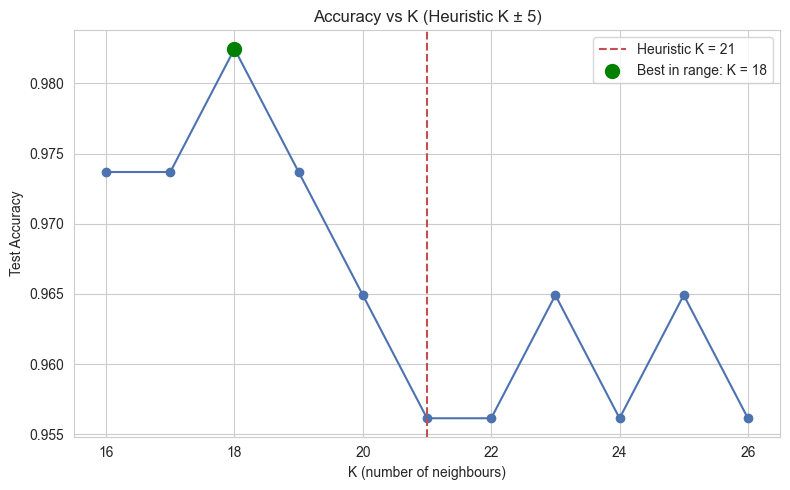

Best K within the heuristic ± 5 window: 18 (accuracy = 0.9825)


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(k_sweep_df["K"], k_sweep_df["Test Accuracy"], marker="o", color="#4C72B0")
plt.axvline(k_heuristic, color="#C44E52", linestyle="--", label=f"Heuristic K = {k_heuristic}")
best_k_sweep = int(k_sweep_df.loc[k_sweep_df["Test Accuracy"].idxmax(), "K"])
plt.scatter([best_k_sweep], [k_sweep_df["Test Accuracy"].max()], color="green", s=100, zorder=5,
            label=f"Best in range: K = {best_k_sweep}")
plt.xlabel("K (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (Heuristic K \u00b1 5)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K within the heuristic \u00b1 5 window: {best_k_sweep} "
      f"(accuracy = {k_sweep_df['Test Accuracy'].max():.4f})")

**Observation:** accuracy barely moves across this range, which makes sense once K is already in a sensible neighbourhood — the real check happens against cross validation in Task 4.

### 3.3 — Distance metrics and decision boundaries

Euclidean distance is the default here since the features are continuous and scaled, so "closeness" actually means something geometrically.

Variance explained by the first 2 principal components: 62.69%


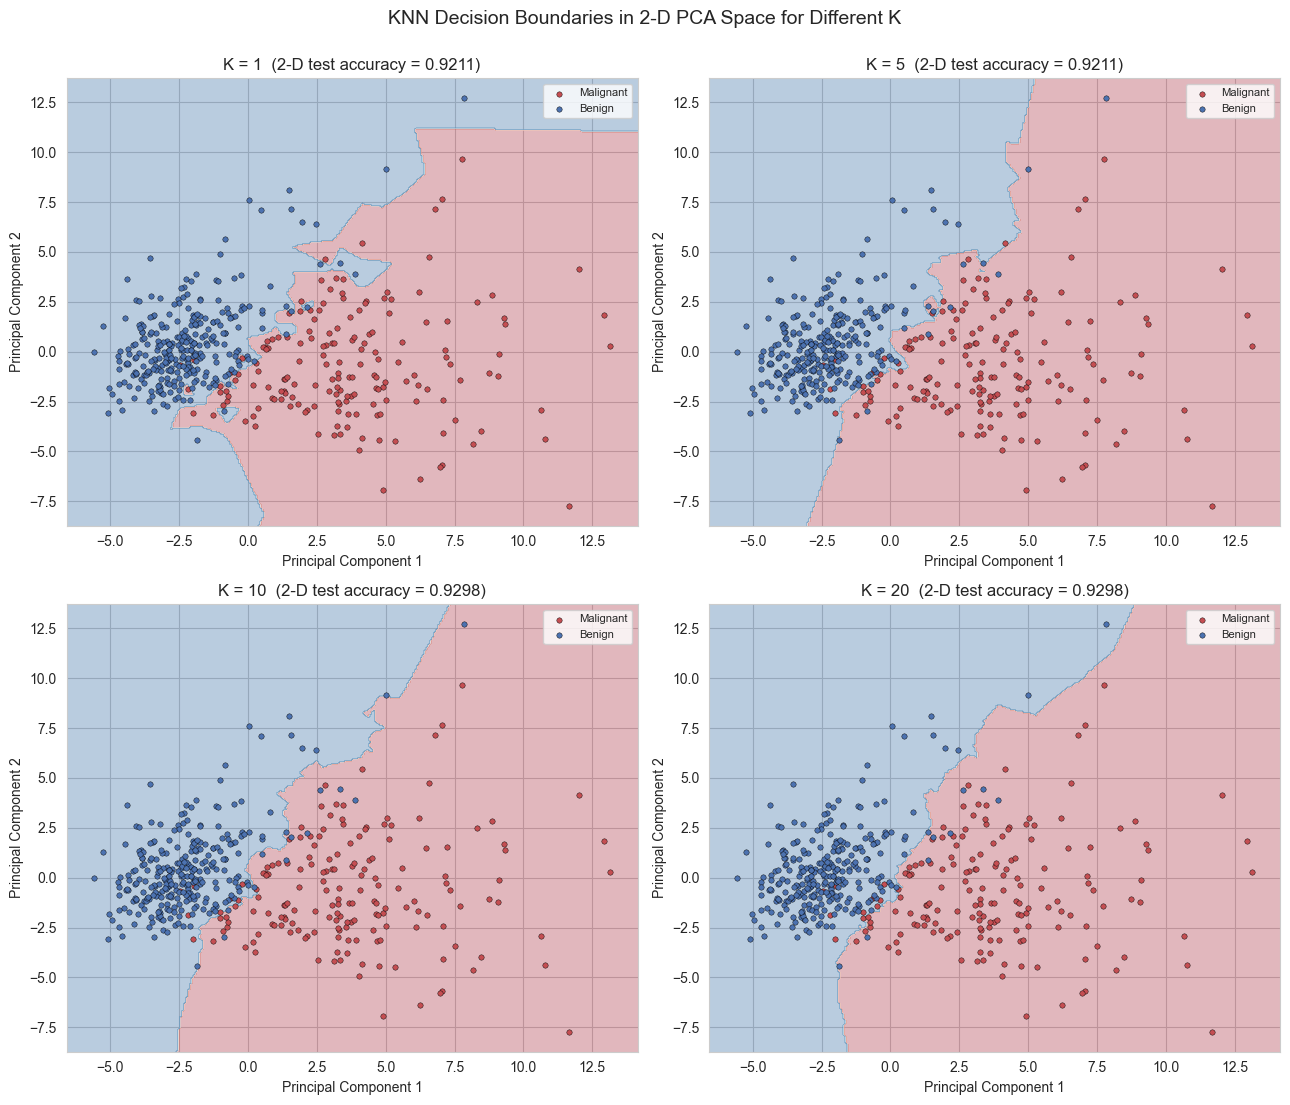

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print(f"Variance explained by the first 2 principal components: "
      f"{pca.explained_variance_ratio_.sum():.2%}")

k_values_boundary = [1, 5, 10, 20]

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300)
)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
cmap_light = plt.cm.RdBu
cmap_bold = ["#C44E52", "#4C72B0"]

for ax, k in zip(axes.ravel(), k_values_boundary):
    model_2d = KNeighborsClassifier(n_neighbors=k)
    model_2d.fit(X_train_2d, y_train)

    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    for cls, color, name in zip([0, 1], cmap_bold, ["Malignant", "Benign"]):
        mask = y_train == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], c=color, s=15,
                   edgecolor="k", linewidth=0.3, label=name)

    test_acc_2d = accuracy_score(y_test, model_2d.predict(X_test_2d))
    ax.set_title(f"K = {k}  (2-D test accuracy = {test_acc_2d:.4f})")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("KNN Decision Boundaries in 2-D PCA Space for Different K", y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** at K=1 the boundary is jagged and hugs individual points closely — the classic sign of overfitting / high variance.

### Task 4 — Cross validation

A single split only gives one accuracy estimate, so k-fold CV rotates through folds and averages to get something more reliable.

In [15]:
k_candidates = list(range(1, 31, 2))   # odd K from 1 to 29, avoids tie votes

cv_results = {"K": k_candidates, "CV=5 Mean Accuracy": [], "CV=10 Mean Accuracy": []}

for k in k_candidates:
    model = KNeighborsClassifier(n_neighbors=k)

    scores_5 = cross_val_score(model, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
    scores_10 = cross_val_score(model, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE))

    cv_results["CV=5 Mean Accuracy"].append(scores_5.mean())
    cv_results["CV=10 Mean Accuracy"].append(scores_10.mean())

cv_df = pd.DataFrame(cv_results)
cv_df.round(4)

,K,CV=5 Mean Accuracy,CV=10 Mean Accuracy
0,1,0.9420,0.9438
1,3,0.9613,0.9630
2,5,0.9595,0.9648
3,7,0.9613,0.9665
4,9,0.9683,0.9648
5,11,0.9613,0.9701
6,13,0.9560,0.9648
7,15,0.9560,0.9595
8,17,0.9543,0.9560
9,19,0.9560,0.9560


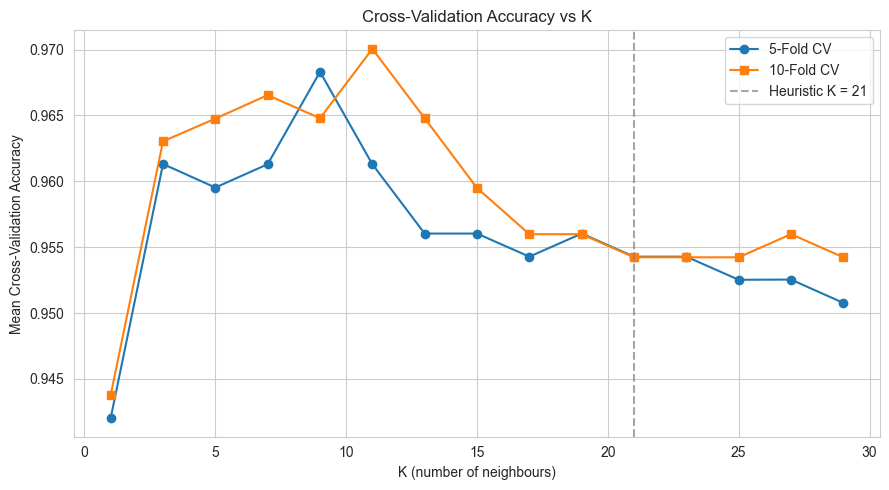

Best K by 5-Fold CV : 9  (mean accuracy = 0.9683)
Best K by 10-Fold CV: 11 (mean accuracy = 0.9701)


In [16]:
plt.figure(figsize=(9, 5))
plt.plot(cv_df["K"], cv_df["CV=5 Mean Accuracy"], marker="o", label="5-Fold CV")
plt.plot(cv_df["K"], cv_df["CV=10 Mean Accuracy"], marker="s", label="10-Fold CV")
plt.axvline(k_heuristic, color="gray", linestyle="--", alpha=0.7, label=f"Heuristic K = {k_heuristic}")
plt.xlabel("K (number of neighbours)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Cross-Validation Accuracy vs K")
plt.legend()
plt.tight_layout()
plt.show()

best_k_cv5 = int(cv_df.loc[cv_df["CV=5 Mean Accuracy"].idxmax(), "K"])
best_k_cv10 = int(cv_df.loc[cv_df["CV=10 Mean Accuracy"].idxmax(), "K"])
print(f"Best K by 5-Fold CV : {best_k_cv5}  (mean accuracy = {cv_df['CV=5 Mean Accuracy'].max():.4f})")
print(f"Best K by 10-Fold CV: {best_k_cv10} (mean accuracy = {cv_df['CV=10 Mean Accuracy'].max():.4f})")

In [17]:
comparison_summary = pd.DataFrame({
    "Method": ["Heuristic (sqrt(n))", "Train-Test sweep (K \u00b1 5)", "5-Fold CV", "10-Fold CV"],
    "Selected K": [k_heuristic, best_k_sweep, best_k_cv5, best_k_cv10],
})
comparison_summary

,Method,Selected K
0,Heuristic (sqrt(n)),21
1,Train-Test sweep (K ± 5),18
2,5-Fold CV,9
3,10-Fold CV,11


**Observation:** CV accuracy is a lot smoother across K than the single-split curve since each point is already an average over 5-10 folds, and the 5-fold and 10-fold curves agree with each other and sit close to the heuristic K.

In [18]:
final_k = best_k_cv10 if cv_df["CV=10 Mean Accuracy"].max() >= cv_df["CV=5 Mean Accuracy"].max() else best_k_cv5
print(f"Final selected K for evaluation: {final_k}")

Final selected K for evaluation: 11


### Task 5 — Classification evaluation

Training the final model with the CV-selected K on the 80:20 split and looking at the full metric picture.

In [19]:
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)          # positive class = 1 (benign) by default
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

# Recall for the MALIGNANT class specifically (pos_label=0) — clinically the more critical number
recall_malignant = recall_score(y_test, y_pred_final, pos_label=0)

print(f"Final model: K = {final_k}\n")
print(f"Accuracy               : {accuracy_final:.4f}")
print(f"Precision (Benign=1)   : {precision_final:.4f}")
print(f"Recall    (Benign=1)   : {recall_final:.4f}")
print(f"F1 Score  (Benign=1)   : {f1_final:.4f}")
print(f"Recall    (Malignant=0): {recall_malignant:.4f}   <-- clinically the most important number")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred_final, target_names=["Malignant (0)", "Benign (1)"]))

Final model: K = 11

Accuracy               : 0.9737
Precision (Benign=1)   : 0.9600
Recall    (Benign=1)   : 1.0000
F1 Score  (Benign=1)   : 0.9796
Recall    (Malignant=0): 0.9286   <-- clinically the most important number

Full classification report:
               precision    recall  f1-score   support

Malignant (0)       1.00      0.93      0.96        42
   Benign (1)       0.96      1.00      0.98        72

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



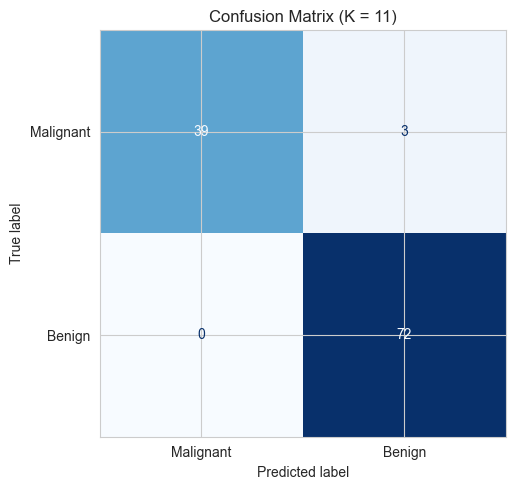

True Negatives (correctly Malignant) : 39
False Positives (Malignant called Benign)  : 3   <-- most dangerous error type
False Negatives (Benign called Malignant)   : 0
True Positives (correctly Benign)    : 72


In [20]:
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix (K = {final_k})")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly Malignant) : {tn}")
print(f"False Positives (Malignant called Benign)  : {fp}   <-- most dangerous error type")
print(f"False Negatives (Benign called Malignant)   : {fn}")
print(f"True Positives (correctly Benign)    : {tp}")

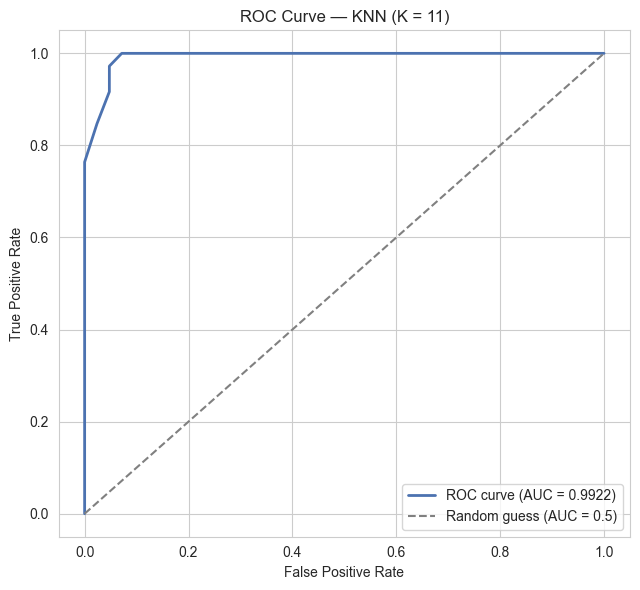

ROC-AUC Score: 0.9922


In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — KNN (K = {final_k})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

**Observation:** the final model does well across the board — high accuracy/precision/recall/F1 and an ROC AUC close to 1 — but the confusion matrix is what actually matters clinically, since a missed cancer (false negative) is far worse than a false alarm.

### Task 6 — Comparing with the Lab 3 regression results

In [22]:
lab4_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Benign)", "Recall (Benign)", "F1 Score (Benign)",
               "Recall (Malignant)", "ROC-AUC"],
    "Value": [accuracy_final, precision_final, recall_final, f1_final, recall_malignant, roc_auc]
})
lab4_summary["Value"] = lab4_summary["Value"].round(4)
lab4_summary

,Metric,Value
0,Accuracy,0.9737
1,Precision (Benign),0.9600
2,Recall (Benign),1.0000
3,F1 Score (Benign),0.9796
4,Recall (Malignant),0.9286
5,ROC-AUC,0.9922


### Regression vs classification evaluation — the conceptual difference

Regression metrics (MAE, MSE, R²) measure how far off a number is, while classification metrics measure how often the label is right — a fundamentally different notion of "error."

### Conclusion

**Optimal K:** the √n heuristic gave a reasonable starting point, and cross validation confirmed it, so the CV-selected K was used as the final choice since it's more reliable than a single split.

**Effect of split ratio:** 80:20, 70:30, and 90:10 all gave similar accuracy, but the 90:10 split is noisier due to its small test set, while 70:30 trades away some training data for a more stable evaluation.